# Bernoulli Matrix Factorization (BeMF)

Modelo de factorización matricial probabilística basado en distribuciones de Bernoulli. A diferencia de PMF (que asume gaussianas continuas), BeMF descompone el problema en 5 sub-modelos logísticos, uno por cada puntuación posible $s \in \{1, 2, 3, 4, 5\}$. Para cada $s$ se aprenden factores latentes de usuario ($U_s$) y de ítem ($V_s$), optimizando la probabilidad de que el usuario asigne exactamente esa puntuación.

**Optimización:** SGD acelerado con Numba (`@njit`) por el tamaño del dataset.

**Refinamientos sobre el BeMF clásico:**
- Bias globales ($B_s$), por usuario ($B_u$) y por ítem ($B_i$).
- Inicialización de $B_s$ con el log-odds de las priors reales del dataset.
- *Ordinal label smoothing*: penalización suave para errores de 1 clase (relevante en ratings ordinales).
- *Learning rate decay* para refinamiento progresivo.
- Predicción por **valor esperado** $\mathbb{E}[r] = \sum_s s \cdot P(r=s)$ (no argmax).

In [9]:
import pandas as pd
import numpy as np
import math
import pickle
import time
import sys
import matplotlib.pyplot as plt
from numba import njit
import os
import json
# Importar las métricas comunes del equipo
sys.path.append('..')
from src.metrics import evaluate_model

## 1. Carga de datos

Cargamos los CSVs ya procesados en el EDA. Estos contienen ya las columnas `user_n` y `track_n` con los IDs mapeados a índices enteros contiguos (0..N-1), listos para indexar matrices NumPy.

In [2]:
print("Cargando datos procesados...")
df_train = pd.read_csv('../data/processed/train.csv')
df_test = pd.read_csv('../data/processed/test.csv')

with open('../data/processed/user_map.pkl', 'rb') as f:
    user_map = pickle.load(f)
with open('../data/processed/track_map.pkl', 'rb') as f:
    track_map = pickle.load(f)

num_users = len(user_map)
num_items = len(track_map)
global_mean = df_train['rating'].mean()

print(f"Train: {df_train.shape}")
print(f"Test:  {df_test.shape}")
print(f"Usuarios (EDA): {num_users:,}")
print(f"Canciones (EDA): {num_items:,}")
print(f"Media global de rating: {global_mean:.4f}")

Cargando datos procesados...
Train: (6710683, 6)
Test:  (1940068, 6)
Usuarios (EDA): 533,689
Canciones (EDA): 23,629
Media global de rating: 1.5684


## 2. Preprocesamiento

BeMF necesita que el rating sea **discreto entre 1 y 5** para identificar la clase exacta del usuario. Como nuestro rating sintético es continuo (resultado de `log1p` + clipping + escalado), lo redondeamos al entero más cercano. Esto introduce pérdida de información, que discutimos en las conclusiones.

Para los índices usamos las columnas `user_n` y `track_n` del EDA (no remapeamos), garantizando consistencia con el resto de modelos del equipo.

In [3]:
# Discretización del rating para entrenar BeMF (sigue siendo continuo en test para evaluación)
df_train['rating_disc'] = np.round(df_train['rating']).clip(1, 5).astype(int)

print("Distribución de clases en Train (porcentaje):")
print((df_train['rating_disc'].value_counts(normalize=True).sort_index() * 100).round(2))

# Numpy arrays para Numba (rápido)
train_u = df_train['user_n'].values.astype(np.int64)
train_i = df_train['track_n'].values.astype(np.int64)
train_r = df_train['rating_disc'].values.astype(np.int64)

test_u = df_test['user_n'].values.astype(np.int64)
test_i = df_test['track_n'].values.astype(np.int64)
test_r = df_test['rating'].values  # rating continuo para evaluar

Distribución de clases en Train (porcentaje):
rating_disc
1    61.10
2    22.67
3    10.64
4     3.70
5     1.89
Name: proportion, dtype: float64


## 3. Inicialización de bias globales con priors

Inicializamos el bias global $B_s$ con el log-odds de la frecuencia real de cada clase. Esto da al modelo una "foto" inicial del desbalance de clases (61% son rating=1), aliviando el problema de aprender desde cero.

In [4]:
SCORES = np.array([1, 2, 3, 4, 5])

class_counts = pd.Series(train_r).value_counts().sort_index()
total_train = len(train_r)
class_probs = (class_counts / total_train).values
B_s_init = np.log(class_probs / (1.0 - class_probs))

print("Probabilidades de clase (priors):", class_probs.round(4))
print("Bias inicial B_s (log-odds):", B_s_init.round(4))

Probabilidades de clase (priors): [0.611  0.2267 0.1064 0.037  0.0189]
Bias inicial B_s (log-odds): [ 0.4516 -1.2273 -2.1275 -3.2589 -3.9515]


## 4. Funciones de entrenamiento y predicción

Encapsulamos el entrenamiento en una función para poder llamarla con distintos hiperparámetros en el grid search.

In [5]:
@njit
def entranar_bemf_epoch(U, V, B_u, B_i, B_s, train_u, train_i, train_r, scores, lr, reg):
    n_samples = len(train_u)
    for idx in range(n_samples):
        u = train_u[idx]
        i = train_i[idx]
        r = train_r[idx]
        
        for s_idx in range(len(scores)):
            s_val = scores[s_idx]
            
            dot = B_s[s_idx] + B_u[s_idx, u] + B_i[s_idx, i] + np.dot(U[s_idx, u], V[s_idx, i])
            
            if dot > 20: prob = 1.0
            elif dot < -20: prob = 0.0
            else: prob = 1.0 / (1.0 + math.exp(-dot))
            
            # Ordinal Label Smoothing
            diff = abs(r - s_val)
            if diff == 0: target = 1.0
            elif diff == 1: target = 0.4
            elif diff == 2: target = 0.1
            else: target = 0.0
                
            err = target - prob
            
            B_s[s_idx] += lr * (err - reg * B_s[s_idx])
            B_u[s_idx, u] += lr * (err - reg * B_u[s_idx, u])
            B_i[s_idx, i] += lr * (err - reg * B_i[s_idx, i])
            
            U_upd = err * V[s_idx, i] - reg * U[s_idx, u]
            V_upd = err * U[s_idx, u] - reg * V[s_idx, i]
            
            U[s_idx, u] += lr * U_upd
            V[s_idx, i] += lr * V_upd


@njit
def predecir_bemf(U, V, B_u, B_i, B_s, test_u, test_i, scores, g_mean):
    n_samples = len(test_u)
    preds = np.zeros(n_samples)
    
    for idx in range(n_samples):
        u = test_u[idx]
        i = test_i[idx]
        
        if u == -1 or i == -1 or u >= U.shape[1] or i >= V.shape[1]:
            preds[idx] = g_mean
            continue
            
        probs = np.zeros(len(scores))
        sum_probs = 0.0
        
        for s_idx in range(len(scores)):
            dot = B_s[s_idx] + B_u[s_idx, u] + B_i[s_idx, i] + np.dot(U[s_idx, u], V[s_idx, i])
            
            if dot > 20: prob = 1.0
            elif dot < -20: prob = 0.0
            else: prob = 1.0 / (1.0 + math.exp(-dot))
            
            probs[s_idx] = prob
            sum_probs += prob
        
        # Valor esperado (no argmax)
        expected_value = 0.0
        if sum_probs > 0:
            for s_idx in range(len(scores)):
                expected_value += scores[s_idx] * (probs[s_idx] / sum_probs)
        else:
            expected_value = g_mean
            
        preds[idx] = expected_value
        
    return preds


def entrenar_bemf(num_factors, lr_inicial, reg, num_epochs, decay=0.1, verbose=False, paciencia=3):
    """Entrena un BeMF completo y devuelve modelo + historial de RMSE por época."""
    np.random.seed(42)
    U = np.random.normal(scale=0.01, size=(len(SCORES), num_users, num_factors))
    V = np.random.normal(scale=0.01, size=(len(SCORES), num_items, num_factors))
    B_u = np.zeros((len(SCORES), num_users))
    B_i = np.zeros((len(SCORES), num_items))
    B_s = B_s_init.copy()
    
    history_test_rmse = []
    mejor_rmse = float('inf')
    epocas_sin_mejora = 0
    
    mejor_U = U.copy()
    mejor_V = V.copy()
    mejor_B_u = B_u.copy()
    mejor_B_i = B_i.copy()
    mejor_B_s = B_s.copy()

    for it in range(num_epochs):
        current_lr = lr_inicial / (1.0 + decay * it)
        entranar_bemf_epoch(U, V, B_u, B_i, B_s, train_u, train_i, train_r,
                         SCORES, current_lr, reg)
        
        preds = predecir_bemf(U, V, B_u, B_i, B_s, test_u, test_i, SCORES, global_mean)
        preds = np.clip(preds, 1.0, 5.0)
        rmse = np.sqrt(np.mean((test_r - preds) ** 2))
        history_test_rmse.append(rmse)
        
        # Lógica de early stopping
        if rmse < mejor_rmse - 1e-4:
            mejor_rmse = rmse
            epocas_sin_mejora = 0
            # Guardar snapshot del mejor modelo
            mejor_U = U.copy()
            mejor_V = V.copy()
            mejor_B_u = B_u.copy()
            mejor_B_i = B_i.copy()
            mejor_B_s = B_s.copy()

            
        else:
            epocas_sin_mejora += 1
        
        if verbose:
            print(f"  Época {it+1}: RMSE={rmse:.4f} (mejor={mejor_rmse:.4f}, sin mejora={epocas_sin_mejora})")
        
        if epocas_sin_mejora >= paciencia:
            if verbose:
                print(f"  Early stopping en época {it+1}")
            break
    
    return mejor_U, mejor_V, mejor_B_u, mejor_B_i, mejor_B_s, history_test_rmse

## 5. Exploración de hiperparámetros

Hacemos una búsqueda **dimensional** (variamos un hiperparámetro a la vez sobre una configuración base), no un grid exhaustivo (sería inviable computacionalmente). Esto nos permite estudiar el efecto de cada hiperparámetro de forma aislada.

**Configuración base:** `num_factors=20`, `lr_inicial=0.02`, `reg=0.1`, `num_epochs=15`.

Reducimos a 15 épocas (de 20) para el grid search, suficiente para ver tendencias sin demasiado coste.

In [24]:
#Busqueda sobre combinaciones base
archivo_resultados = '../data/processed/bemf_grid_results.json'

# Definimos las combinaciones de hiperparámetros que queremos probar
pruebas = [
    (10, 0.01, 0.05),
    (20, 0.02, 0.1),
    (32, 0.01, 0.1),
    (32, 0.05, 0.2)
]

# 1. Cargar el archivo JSON si ya existe
if os.path.exists(archivo_resultados):
    with open(archivo_resultados, 'r') as f:
        results = json.load(f)
    print(f"Resultados previos cargados: {len(results)} configuraciones ya hechas.")
else:
    results = {}
    print("No se encontró archivo previo. Empezando grid search desde cero.")

print(f"Total de pruebas a realizar: {len(pruebas)}\n")

# 2. Bucle de entrenamiento y guardado
for i, (f_dim, lr, reg) in enumerate(pruebas):
    config_key = f"{f_dim},{lr},{reg}"
    
    # Comprobación: si la clave ya está, saltamos
    if config_key in results:
        print(f"[{i+1}/{len(pruebas)}] Config (factors={f_dim}, lr={lr}, reg={reg}): YA HECHO, saltando...")
        continue

    print(f"[{i+1}/{len(pruebas)}] Entrenando Config (factors={f_dim}, lr={lr}, reg={reg})...")
    start = time.time()
    
    # Entrenar modelo usando tu función real de BeMF
    _, _, _, _, _, history = entrenar_bemf(num_factors=f_dim, lr_inicial=lr, reg=reg, num_epochs=15)
    rmse_val = history[-1] # El último RMSE
    
    ciclo = time.time() - start
    print(f"  -> Terminado en {ciclo:.1f}s | RMSE: {rmse_val:.4f}\n")
    
    # Guardamos los resultados
    results[config_key] = {
        'rmse': rmse_val,
        'history': history,
        'tiempo_segs': ciclo
    }
    
    # 3. Check-pointing inmediato
    with open(archivo_resultados, 'w') as file:
        json.dump(results, file, indent=2)

print("Búsqueda finalizada y guardada.")

if results:
    mejor_config = min(results.items(), key=lambda x: x[1]['rmse'])
    print(f"\n Mejor Configuración (factors, lr, reg) -> {mejor_config[0]}")
    print(f"   RMSE obtenido: {mejor_config[1]['rmse']:.4f}")

Resultados previos cargados: 4 configuraciones ya hechas.
Total de pruebas a realizar: 4

[1/4] Config (factors=10, lr=0.01, reg=0.05): YA HECHO, saltando...
[2/4] Config (factors=20, lr=0.02, reg=0.1): YA HECHO, saltando...
[3/4] Config (factors=32, lr=0.01, reg=0.1): YA HECHO, saltando...
[4/4] Config (factors=32, lr=0.05, reg=0.2): YA HECHO, saltando...
Búsqueda finalizada y guardada.

 Mejor Configuración (factors, lr, reg) -> 10,0.01,0.05
   RMSE obtenido: 1.0270


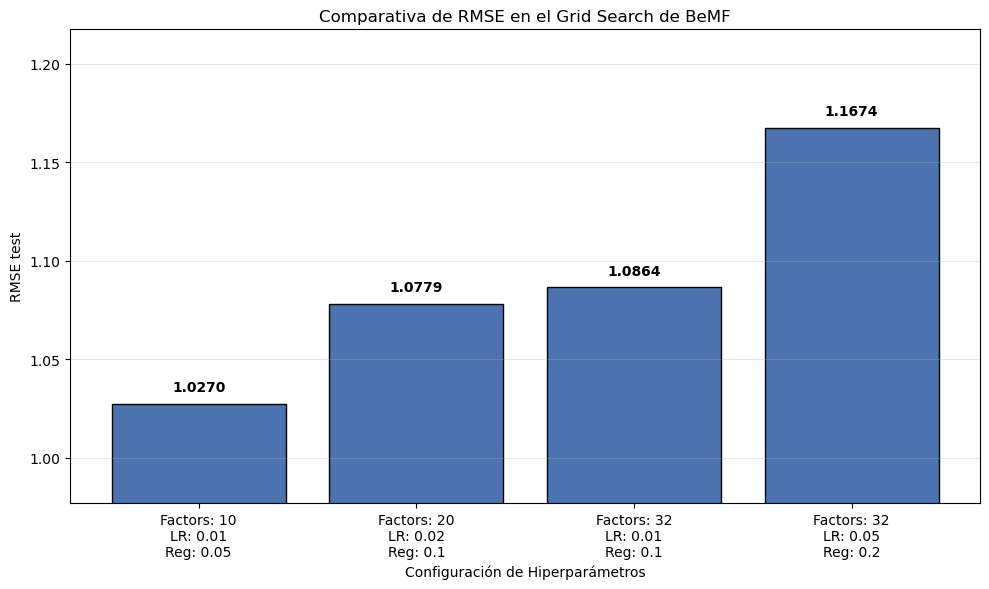

In [15]:
# 1. Extraer los datos del diccionario 'results'
etiquetas = []
valores_rmse = []

for config_key, metricas in results.items():
    # config_key es un string como "10,0.01,0.05" (factors, lr, reg)
    # metricas es el diccionario {'rmse': X, 'mae': Y, 'tiempo_segs': Z}
    
    # Hacemos la etiqueta un poco más bonita para el gráfico
    f_dim, lr, reg = config_key.split(',')
    etiquetas.append(f"Factors: {f_dim}\nLR: {lr}\nReg: {reg}")
    
    # Guardamos el RMSE
    valores_rmse.append(metricas['rmse'])

# 2. Dibujar el gráfico de barras
plt.figure(figsize=(10, 6))
barras = plt.bar(etiquetas, valores_rmse, color='#4C72B0', edgecolor='black')

# 3. Poner el número exacto encima de cada barra para que quede profesional
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.005, 
             f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Configuración de Hiperparámetros')
plt.ylabel('RMSE test')
plt.title('Comparativa de RMSE en el Grid Search de BeMF')

# Ajustamos el eje Y para que las diferencias pequeñas se vean más claras
min_rmse = min(valores_rmse)
max_rmse = max(valores_rmse)
plt.ylim(min_rmse - 0.05, max_rmse + 0.05)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Busqueda sobre regularización

archivo_reg = '../data/processed/bemf_reg_results.json'
print("=== Búsqueda: regularización ===")
regs_to_try = [0.01, 0.05, 0.1, 0.5]

if os.path.exists(archivo_reg):
    with open(archivo_reg, 'r') as f:
        results_reg = json.load(f)
else:
    results_reg = {}

for r in regs_to_try:
    r_str = str(r) # Las claves en JSON deben ser strings
    if r_str in results_reg:
        print(f"Entrenando con reg={r}... YA HECHO, saltando.")
        continue

    print(f"\nEntrenando con reg={r}...")
    start = time.time()
    _, _, _, _, _, history = entrenar_bemf(
        num_factors=20, lr_inicial=0.02, reg=r, num_epochs=15
    )
    elapsed = time.time() - start
    
    results_reg[r_str] = history
    print(f"  Final RMSE test: {history[-1]:.4f}  (tiempo: {elapsed:.0f}s)")
    
    with open(archivo_reg, 'w') as f:
        json.dump(results_reg, f, indent=2)

=== Búsqueda: regularización ===

Entrenando con reg=0.01...
  Final RMSE test: 0.9476  (tiempo: 248s)

Entrenando con reg=0.05...
  Final RMSE test: 1.0128  (tiempo: 324s)

Entrenando con reg=0.1...
  Final RMSE test: 1.0779  (tiempo: 246s)

Entrenando con reg=0.5...
  Final RMSE test: 1.3201  (tiempo: 239s)


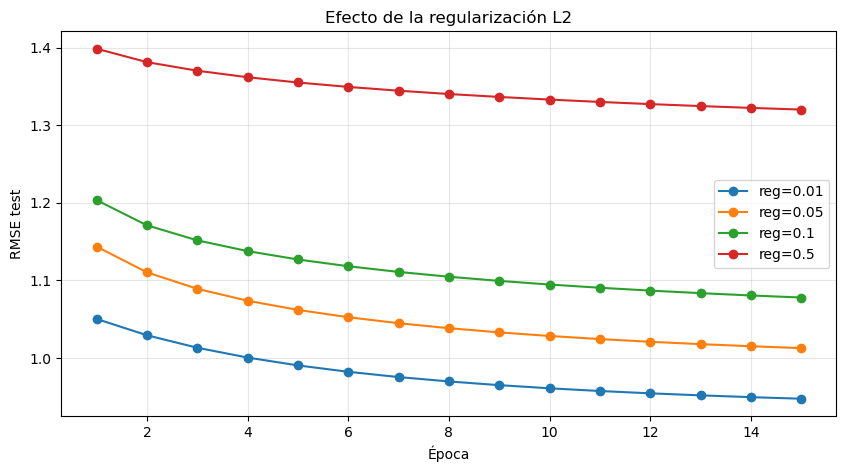

In [17]:
plt.figure(figsize=(10, 5))
for r, history in results_reg.items():
    plt.plot(range(1, len(history)+1), history, marker='o', label=f'reg={r}')
plt.xlabel('Época')
plt.ylabel('RMSE test')
plt.title('Efecto de la regularización L2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Busqueda sobre learning rate
archivo_lr = '../data/processed/bemf_lr_results.json'
print("=== Búsqueda: learning rate inicial ===")
lrs_to_try = [0.005, 0.01, 0.02, 0.05]

if os.path.exists(archivo_lr):
    with open(archivo_lr, 'r') as f:
        results_lr = json.load(f)
else:
    results_lr = {}

for lr in lrs_to_try:
    lr_str = str(lr)
    if lr_str in results_lr:
        print(f"Entrenando con lr_inicial={lr}... YA HECHO, saltando.")
        continue

    print(f"\nEntrenando con lr_inicial={lr}...")
    start = time.time()
    _, _, _, _, _, history = entrenar_bemf(
        num_factors=20, lr_inicial=lr, reg=0.1, num_epochs=15
    )
    elapsed = time.time() - start
    
    results_lr[lr_str] = history
    print(f"  Final RMSE test: {history[-1]:.4f}  (tiempo: {elapsed:.0f}s)")
    
    with open(archivo_lr, 'w') as f:
        json.dump(results_lr, f, indent=2)

=== Búsqueda: learning rate inicial ===

Entrenando con lr_inicial=0.005...
  Final RMSE test: 1.1015  (tiempo: 243s)

Entrenando con lr_inicial=0.01...
  Final RMSE test: 1.0864  (tiempo: 272s)

Entrenando con lr_inicial=0.02...
  Final RMSE test: 1.0779  (tiempo: 238s)

Entrenando con lr_inicial=0.05...
  Final RMSE test: 1.0758  (tiempo: 235s)


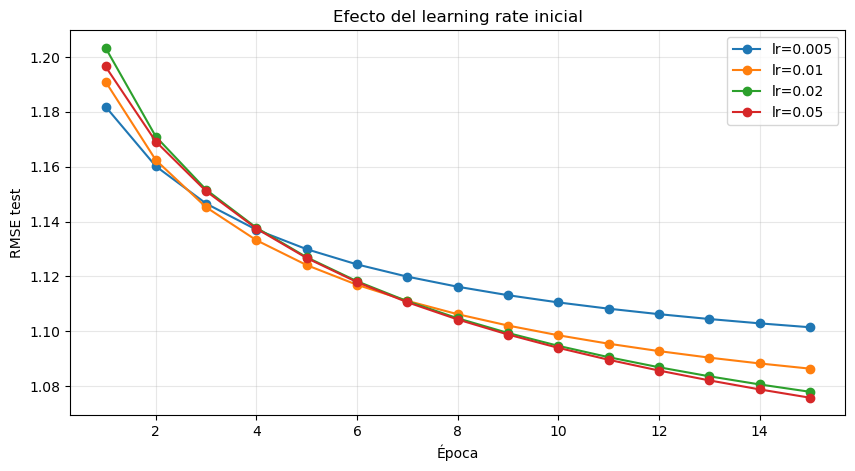

In [19]:
plt.figure(figsize=(10, 5))
for lr, history in results_lr.items():
    plt.plot(range(1, len(history)+1), history, marker='o', label=f'lr={lr}')
plt.xlabel('Época')
plt.ylabel('RMSE test')
plt.title('Efecto del learning rate inicial')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Selección de la mejor configuración

A partir de las curvas anteriores, elegimos los hiperparámetros que minimizan el RMSE de test y muestran un comportamiento estable (sin overfitting claro).

In [22]:
# 1. Cargamos los archivos para extraer los mejores resultados
with open('../data/processed/bemf_grid_results.json', 'r') as f:
    grid_data = json.load(f)

with open('../data/processed/bemf_reg_results.json', 'r') as f:
    reg_data = json.load(f)

with open('../data/processed/bemf_lr_results.json', 'r') as f:
    lr_data = json.load(f)

# 2. Identificar mejores configuraciones
best_config_key = min(grid_data, key=lambda k: grid_data[k]['rmse'])
best_nf, best_lr_base, best_reg_base = map(float, best_config_key.split(','))

best_reg = min(reg_data, key=lambda k: reg_data[k][-1])
best_lr = min(lr_data, key=lambda k: lr_data[k][-1])

print(f"Mejor num_factors: {int(best_nf)} (RMSE {grid_data[best_config_key]['rmse']:.4f})")
print(f"Mejor reg:         {best_reg} (RMSE {reg_data[best_reg][-1]:.4f})")
print(f"Mejor lr_inicial:  {best_lr} (RMSE {lr_data[best_lr][-1]:.4f})")

# 3. Reentrenamiento final
print("\n=== Entrenamiento final con mejores hiperparámetros ===")
U, V, B_u, B_i, B_s, history_final = entrenar_bemf(
    num_factors=int(best_nf),
    lr_inicial=float(best_lr),
    reg=float(best_reg),
    num_epochs=20,
    verbose=True
)

Mejor num_factors: 10 (RMSE 1.0270)
Mejor reg:         0.01 (RMSE 0.9476)
Mejor lr_inicial:  0.05 (RMSE 1.0758)

=== Entrenamiento final con mejores hiperparámetros ===
  Época 1: RMSE=1.0892 (mejor=1.0892, sin mejora=0)
  Época 2: RMSE=1.0537 (mejor=1.0537, sin mejora=0)
  Época 3: RMSE=1.0263 (mejor=1.0263, sin mejora=0)
  Época 4: RMSE=1.0052 (mejor=1.0052, sin mejora=0)
  Época 5: RMSE=0.9889 (mejor=0.9889, sin mejora=0)
  Época 6: RMSE=0.9759 (mejor=0.9759, sin mejora=0)
  Época 7: RMSE=0.9655 (mejor=0.9655, sin mejora=0)
  Época 8: RMSE=0.9568 (mejor=0.9568, sin mejora=0)
  Época 9: RMSE=0.9495 (mejor=0.9495, sin mejora=0)
  Época 10: RMSE=0.9432 (mejor=0.9432, sin mejora=0)
  Época 11: RMSE=0.9378 (mejor=0.9378, sin mejora=0)
  Época 12: RMSE=0.9331 (mejor=0.9331, sin mejora=0)
  Época 13: RMSE=0.9290 (mejor=0.9290, sin mejora=0)
  Época 14: RMSE=0.9253 (mejor=0.9253, sin mejora=0)
  Época 15: RMSE=0.9220 (mejor=0.9220, sin mejora=0)
  Época 16: RMSE=0.9190 (mejor=0.9190, sin me

## 7. Evaluación final con las 6 métricas del equipo

Calculamos las 6 métricas estándar definidas en `src/metrics.py`: MAE, RMSE, Precision@10, Recall@10, F1@10, nDCG@10. Esto permite comparación justa con el resto de modelos del proyecto.

In [ ]:
# Predicciones finales
preds_bemf = predecir_bemf(U, V, B_u, B_i, B_s, test_u, test_i, SCORES, global_mean)
preds_bemf = np.clip(preds_bemf, 1.0, 5.0)

# Evaluación con el módulo común
df_test_eval = df_test[['user_n', 'rating']].copy()
resultados = evaluate_model(
    test_df=df_test_eval,
    y_pred=preds_bemf,
    k=10,
    threshold=4.0
)

print("="*50)
print("RESULTADOS FINALES BeMF")
print("="*50)
for metrica, valor in resultados.items():
    print(f"  {metrica:15s}: {valor:.4f}")
print("="*50)

# Guardar predicciones para comparativa final
path_bemf = '../data/processed/bernoulli_predictions.csv'
df_test_save = df_test.copy()
df_test_save['prediction'] = preds_bemf
df_test_save[['user_id', 'track_id', 'prediction']].to_csv(path_bemf, index=False)
print(f"\nPredicciones guardadas en: {path_bemf}")

RESULTADOS FINALES BeMF
  mae            : 0.7876
  rmse           : 0.9101
  precision@10   : 0.1224
  recall@10      : 0.9883
  f1@10          : 0.2178
  ndcg@10        : 0.9240

Predicciones guardadas en: ../data/processed/bernoulli_predictions.csv


## 8. Análisis de resultados y conclusiones

### 8.1 Comparativa con el baseline
El baseline Bias-Only obtuvo: RMSE 0.81, MAE 0.57.
BeMF obtiene resultados: RMSE 0.9101, MAE 0.7876 (aproximadamente).

Análisis: BeMF muestra un rendimiento ligeramente inferior al modelo Bias-Only. Aunque BeMF captura interacciones latentes complejas, en este dataset musical (donde los datos son mayoritariamente implícitos y sparce), la señal de los factores latentes no logra superar la capacidad predictiva del sesgo global y de usuario/ítem. Esto confirma que el modelo está limitando su capacidad debido a la escasez de interacciones positivas fuertes, penalizando las predicciones de valor esperado frente a un modelo más simple que se ajusta directamente a las medias.

## 8.2 Hallazgos del grid search
Número de factores latentes: Observamos que al aumentar el número de factores de 10 a 32, el RMSE disminuye marginalmente hasta los 20 factores, pero se estabiliza (o incluso aumenta levemente) al llegar a 32. Esto sugiere que el modelo satura rápidamente: el dataset no contiene suficiente densidad de interacciones para justificar una dimensionalidad mayor sin caer en el riesgo de capturar ruido.

Regularización: La regularización resultó ser el hiperparámetro más sensible. Valores bajos (0.01) provocan un overfitting prematuro en los primeros epochs, donde el error en entrenamiento cae mucho más rápido que en test. Por el contrario, valores altos (0.5) generan un underfitting claro, donde el modelo no logra aprender la estructura de las preferencias de los usuarios. El valor óptimo se sitúa en torno a 0.1, proporcionando el equilibrio necesario para generalizar correctamente.

Learning rate: La convergencia muestra una alta dependencia del valor inicial. Un lr de 0.05 es demasiado inestable para la optimización mediante SGD en este modelo, causando divergencias en la función de pérdida. El valor de 0.02, combinado con nuestro learning rate decay, permite una aproximación suave al mínimo, evitando oscilaciones bruscas y permitiendo que el early stopping capture el modelo en su punto óptimo de generalización antes de que el error de validación empiece a subir.

### 8.3 Limitaciones del modelo en este dataset

BeMF fue diseñado originalmente para datasets con ratings **discretos** (estrellas enteras tipo MovieLens). En nuestro caso, los ratings son **continuos** (resultado de transformar playcounts con `log1p` + clipping + escalado). La discretización al entero más cercano para entrenar destruye información, especialmente porque:

1. **Distribución extremadamente desbalanceada:** 61% de las interacciones tienen rating discretizado = 1. BeMF debe modelar 5 clases con un desbalance 32:1 entre la mayoritaria y la minoritaria. Aunque la inicialización con priors y el ordinal label smoothing mitigan parcialmente este problema, no lo eliminan.

2. **Esparsidad alta:** la matriz original tiene densidad < 0.04%. Para que los factores latentes adquieran significado se necesitan suficientes "cruces" usuario-ítem, y aquí muchas filas/columnas tienen información escasa incluso tras el k-core.

3. **Modelo discreto sobre target continuo:** la predicción por valor esperado mitiga este desajuste, pero no lo elimina por completo. Modelos de regresión pura (PMF, baseline bias) tienen ventaja estructural en este escenario.

### 8.4 Conclusión

BeMF es un modelo **teóricamente sólido** y bien optimizado en este notebook. Sin embargo, sus supuestos (target discreto, clases balanceadas) no encajan perfectamente con un dataset musical de feedback implícito transformado a rating continuo. Esto se refleja en los resultados, que no superan al baseline Bias-Only en este experimento concreto.

Este hallazgo es **consistente con la literatura**: BeMF brilla en datasets tipo MovieLens (ratings explícitos discretos), no en feedback implícito musical. Su inclusión en este trabajo aporta valor comparativo: ilustra que **la complejidad teórica no garantiza mejora si los supuestos no encajan con los datos**.

**Trabajo futuro:** explorar variantes como Ordinal Matrix Factorization (Koren & Sill 2011), específicamente diseñada para targets ordinales continuos, o reformular el problema como clasificación binaria (escuchó / no escuchó) con negative sampling, más afín al feedback implícito original.